In [ ]:
import oqupy
import oqupy.operators as op
import numpy as np
from oqupy.iTEBD_TEMPO_useoqupybath import iTEBD_TEMPO_oqupy
from oqupy.process_tensor import TTInvariantProcessTensor
from oqupy.tti_tempo import TTITempo
from oqupy.tti_tempo import TTITempoCounting
import matplotlib.pyplot as plt


from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from scipy.optimize import minimize,Bounds

pt_parameters = {'epsrel':10**(-7),
                 'alpha':0.1,
                 'omega_cutoff':1,                 
                 'temp':0.131,
                 'dt':0.25}

omega_cutoff = pt_parameters['omega_cutoff']
alpha = pt_parameters['alpha']
temperature = pt_parameters['temp']
epsrel = pt_parameters['epsrel']
# dt = 1./omega_cutoff/np.sqrt(3)
dt=pt_parameters['dt']
tcut=27

Rho_0=oqupy.operators.spin_dm('x+')

alpha=0.1

Rho_0=oqupy.operators.spin_dm('mixed')


# spectral density (without cutoff)
def j(w):
    return 2*alpha*w


In [ ]:
correlations = oqupy.PowerLawSD(alpha=alpha,
                                zeta=1,
                                cutoff=omega_cutoff,
                                cutoff_type='exponential',
                                temperature=temperature)
bath = oqupy.Bath(op.sigma("z")/2.0, correlations)
parameters=oqupy.TempoParameters(dt=dt,epsrel=epsrel,dkmax=int(tcut/dt)+1)


In [ ]:
u=0.01
correlationscf=oqupy.bath_correlations.CustomCountingSD(j_function=j,cutoff=omega_cutoff,u=u,
                                                 cutoff_type='exponential',temperature=temperature)

bathcf = oqupy.Bath(op.sigma("z")/2.0, correlationscf)

In [ ]:
pt_var=TTITempo(bath,start_time=0.0,parameters=parameters)
process_tensor_var = pt_var.get_process_tensor()

pt_varcf=TTITempoCounting(bathcf,start_time=0.0,parameters=parameters)
process_tensor_varcf = pt_varcf.get_process_tensor()


building influence functional:  19%|█▉        | 21/109 [00:00<00:00, 199.79it/s]

building influence functional: 100%|██████████| 109/109 [00:26<00:00,  4.04it/s]


rank  378


c:\Users\Administrator\Desktop\Research\OQuPy\oqupy\bath_correlations.py:1165: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  im_int += integrate.quad(im_integrand,
building influence functional:  19%|█▉        | 21/109 [00:00<00:00, 205.40it/s]

building influence functional: 100%|██████████| 109/109 [00:27<00:00,  3.96it/s]


rank  386


In [28]:
import dill 
t_prot=800

file_name1='results/zero_control/{0}ps/optimization_simplemodel_{0}ps'.format(t_prot)
with open(file_name1,'rb') as f:
    opt_dict=dill.load(f)

In [29]:
from scipy.interpolate import interp1d
#processtensor.length=100
opt_control=opt_dict['result'].x
delta_t = interp1d(np.linspace(0,t_prot,len(opt_control)),opt_control)
def hamiltonian_t(t):
    return delta_t(t)*oqupy.operators.sigma("x")/2

system = oqupy.TimeDependentSystem(hamiltonian_t)

--> Compute dynamics:
  5.6%  223 of 4000 [##--------------------------------------] 00:00:15

KeyboardInterrupt: 

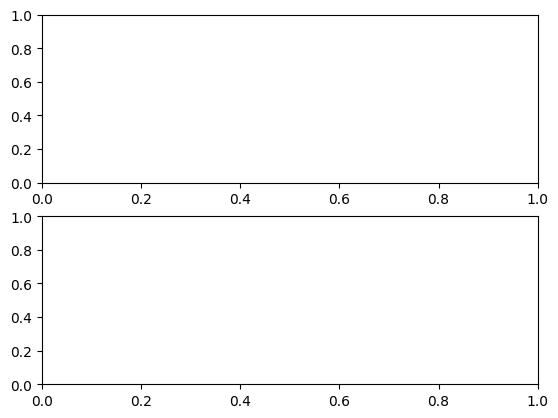

  5.6%  223 of 4000 [##--------------------------------------] 00:01:09

In [30]:



fig,axs=plt.subplots(2)

num_steps=int(t_prot/dt)

# compute dynamics

dynamics=oqupy.compute_dynamics(
process_tensor=process_tensor_var,        
system=system,
initial_state=Rho_0,
start_time=0,
num_steps=num_steps)
t, s_x = dynamics.expectations(op.sigma('x'), real=True)

# compute heats

dynamicscf = oqupy.compute_dynamics(
process_tensor=process_tensor_varcf,        
system=system,
initial_state=Rho_0,
start_time=0,
num_steps=num_steps)

heats=dynamicscf.states.trace(axis1=1,axis2=2).imag/u

axs[0].plot(t,heats,label=t_prot)
axs[0].set_xlabel(r'$t$')
axs[0].set_ylabel(r'$\langle Q \rangle$')
axs[1].plot(t,s_x)
axs[1].set_xlabel(r'$t$')
axs[1].set_ylabel(r'$\langle \sigma_x \rangle$')
plt.legend()
plt.show()


In [ ]:
dt=0.1
epsrel=pt_parameters['epsrel']/10
tcut=27

finer_parameters=oqupy.TempoParameters(dt=dt,epsrel=epsrel,dkmax=int(tcut/dt)+1)


pt_var=TTITempo(bath,start_time=0.0,parameters=finer_parameters)
process_tensor_var = pt_var.get_process_tensor()

pt_varcf=TTITempoCounting(bathcf,start_time=0.0,parameters=finer_parameters)
process_tensor_varcf = pt_varcf.get_process_tensor()

building influence functional:   8%|▊         | 21/271 [00:00<00:01, 183.46it/s]

building influence functional: 100%|██████████| 271/271 [08:11<00:00,  1.81s/it]


rank  877


c:\Users\Administrator\Desktop\Research\OQuPy\oqupy\bath_correlations.py:1160: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  re_int += integrate.quad(re_integrand,
c:\Users\Administrator\Desktop\Research\OQuPy\oqupy\bath_correlations.py:1165: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  im_int += integrate.quad(im_integrand,
building influence functional:   8%|▊         | 22/271 [00:00<00:01, 200.78it/s]

building influence functional: 100%|██████████| 271/271 [10:59<00:00,  2.43s/it]


rank  981


In [ ]:
file_name1='processtensor_fine_simplemodel'
with open(file_name1,'rb') as f:
    process_tensor_var=dill.load(f)

file_name1='processtensorCF_fine_simplemodel'
with open(file_name1,'rb') as f:
    process_tensor_var=dill.load(f)

  5.6%  223 of 4000 [##--------------------------------------] 00:02:33

In [ ]:
# serialization of process tensor (optional)
import dill

# processtensor_simplemodel
file_name1='results/processtensors/processtensor_dt=0.2_ps=-7.0_tcut=50'
with open(file_name1,'rb') as f:
    process_tensor_var=dill.load(f)

# processtensor_simplemodel
file_name2='results/processtensors/processtensorCF_dt=0.2_ps=-8.0_tcut=50'
with open(file_name2,'rb') as f:
    process_tensor_varcf=dill.load(f)

with open('results/zero_control_0.2ps_8/100ps/optimization_simplemodel_100ps', 'rb') as f:
    opt_dict = dill.load(f)
    opt_control = opt_dict['result'].x

omega_cutoff = 1
temperature = 0.131

epsrel=10**(-8)
dt=0.2
tcut=50
u=0.01


In [ ]:
<<<<<<< local
fig,axs=plt.subplots(2)

num_steps=int(t_prot/dt)

# compute dynamics

dynamics=oqupy.compute_dynamics(
process_tensor=process_tensor_var,        
system=system,
initial_state=Rho_0,
start_time=0,
num_steps=num_steps)
t, s_x = dynamics.expectations(op.sigma('x'), real=True)

# compute heats

dynamicscf = oqupy.compute_dynamics(
process_tensor=process_tensor_varcf,        
system=system,
initial_state=Rho_0,
start_time=0,
num_steps=num_steps)

heats=dynamicscf.states.trace(axis1=1,axis2=2).imag/u

axs[0].plot(t,heats,label=t_prot)
axs[0].set_xlabel(r'$t$')
axs[0].set_ylabel(r'$\langle Q \rangle$')
axs[1].plot(t,s_x)
axs[1].set_xlabel(r'$t$')
axs[1].set_ylabel(r'$\langle \sigma_x \rangle$')
plt.legend()
plt.show()

In [39]:
print(800/dt)

4000.0


  5.6%  223 of 4000 [##--------------------------------------] 00:38:20

In [33]:
# processtensor_simplemodel
file_name1='processtensor_fine_simplemodel'
with open(file_name1,'wb') as f:
    dill.dump(process_tensor_var,f)

file_name1='processtensorCF_fine_simplemodel'
with open(file_name1,'wb') as f:
    dill.dump(process_tensor_varcf,f)

  5.6%  223 of 4000 [##--------------------------------------] 00:02:06

  5.6%  223 of 4000 [##--------------------------------------] 00:02:31

In [27]:
import os
folder="OQuPy/results/zero_control_finer/{0}ps".format(t_prot)
os.makedirs(folder,exist_ok=True)

optimization_dict={"result":opt_dict['result'],
                   "log":opt_dict['log'],
                   "heatanddynamics":{'dynamics':dynamics,'heat':dynamicscf},
                   "opttime":opt_dict['opttime'],
                   "parameters":finer_parameters
                   }
# optimization result
file_name1=os.path.join(folder,'optimization_simplemodel_{0}ps'.format(t_prot))
with open(file_name1,'wb') as f:
    dill.dump(optimization_dict,f)



In [32]:
process_tensor_varcf.dt
process_tensor_var.dt

0.1

  5.6%  223 of 4000 [##--------------------------------------] 00:02:05